Stroke : سكتة دماغية

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
tf.random.set_seed(42)

In [2]:
df = pd.read_csv('stroke.csv')
df.head(7)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0.5,0.816895,0.0,1.0,1.0,0.50,1.0,0.801265,0.301260,0.333333,1
1,0.0,0.743652,0.0,0.0,1.0,0.75,0.0,0.679023,0.212981,0.666667,1
2,0.5,0.975586,0.0,1.0,1.0,0.50,0.0,0.234512,0.254296,0.666667,1
3,0.0,0.597168,0.0,0.0,1.0,0.50,1.0,0.536008,0.276060,1.000000,1
4,0.0,0.963379,1.0,0.0,1.0,0.75,0.0,0.549349,0.156930,0.666667,1
5,0.5,0.987793,0.0,0.0,1.0,0.50,1.0,0.605161,0.214204,0.333333,1
6,0.5,0.902344,1.0,1.0,1.0,0.50,0.0,0.069107,0.195876,0.666667,1


In [3]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [4]:
df['stroke'].unique()

array([1, 0])

In [5]:
df['stroke'].value_counts()

,count
stroke,
1,4861
0,4861


In [6]:
x = df.drop(columns = ['stroke'])
y = df['stroke']

In [7]:
'''
The train_test_split function from scikit-learn doesn't know what you are naming your variables. It always outputs exactly four pieces of data in a strict, unchangeable positional order:
First: Training Features ($X$)
Second: Testing Features ($X$)
Third: Training Targets ($y$)
Fourth: Testing Targets ($y$)
'''
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 98)
# random_state = 98 → controls how sklearn splits the data — totally independent from TensorFlow
# tf.random.set_seed(42) → controls how TensorFlow initializes weights — totally independent from sklearn

In [8]:
model = tf.keras.Sequential([
    layers.Dense(64, activation = 'relu', input_shape = x_train.shape[1:]),
    layers.Dropout(0.3), # ← drops 30% of neurons randomly
    layers.Dense(32, activation = 'relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation = 'sigmoid')
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [10]:
# patience --> stop if no improvement for 10 epochs
# restore_best_weights --> go back to the best epoch

early_stop = EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)

In [11]:
'''
If you don't explicitly type batch_size = ? inside model.fit(), your code won't crash and it won't throw an error.

Instead, TensorFlow / Keras will automatically default to a batch size of 32.
'''
history = model.fit(x_train, y_train, epochs = 150, validation_split = 0.2, callbacks = [early_stop])

Epoch 1/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6602 - loss: 0.6167 - val_accuracy: 0.7866 - val_loss: 0.5020
Epoch 2/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7489 - loss: 0.5214 - val_accuracy: 0.7879 - val_loss: 0.4561
Epoch 3/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7748 - loss: 0.4877 - val_accuracy: 0.7937 - val_loss: 0.4451
Epoch 4/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7762 - loss: 0.4788 - val_accuracy: 0.7943 - val_loss: 0.4402
Epoch 5/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7790 - loss: 0.4698 - val_accuracy: 0.8021 - val_loss: 0.4349
Epoch 6/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7880 - loss: 0.4634 - val_accuracy: 0.8033 - val_loss: 0.4302
Epoch 7/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7846 - loss: 0.4626 - val_accuracy: 0.8033 - val_loss: 0.4280
Epoch 8/150
195/195 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7894 - loss: 0.4520 - val_accu

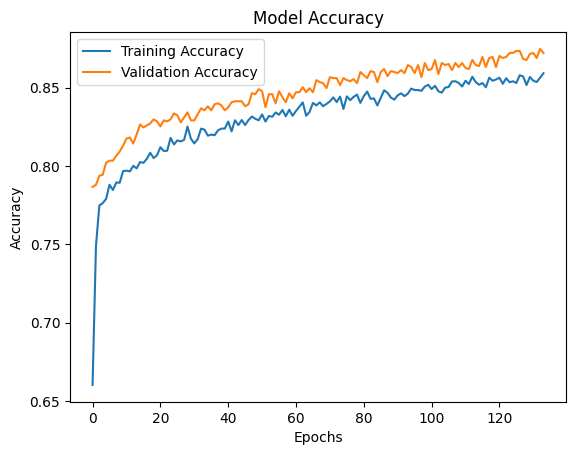

In [12]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

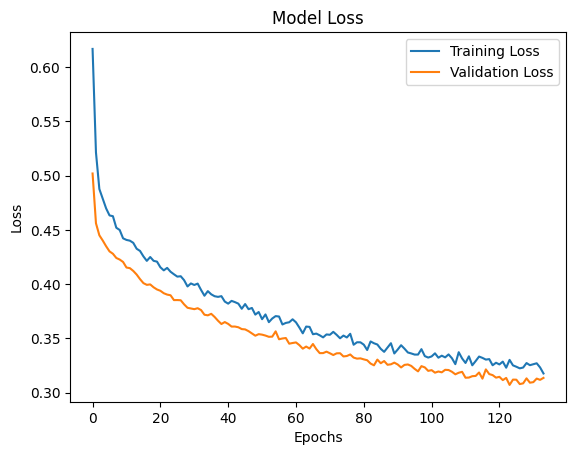

In [13]:
plt.plot(history.history['loss'], label = 'Training Loss')
plt.plot(history.history['val_loss'], label = 'Validation Loss')
plt.title('Model Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
y_pred_probs = model.predict(x_test)

# Convert probabilities to binary 0 or 1 classes
# If probability >= 0.5, it becomes 1 (True), otherwise 0 (False)
y_pred = (y_pred_probs > 0.5).astype(int)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [15]:
acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1_s = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1_s:.4f}")

Accuracy: 0.8586
Precision: 0.8216
Recall: 0.9142
F1-Score: 0.8654


In [16]:
# You use y_train to teach the model, and you use y_test to prove the model actually works.
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8586 - loss: 0.3306
Test Loss: 0.3306
Test Accuracy: 0.8586


In [17]:
cm = confusion_matrix(y_test, y_pred)

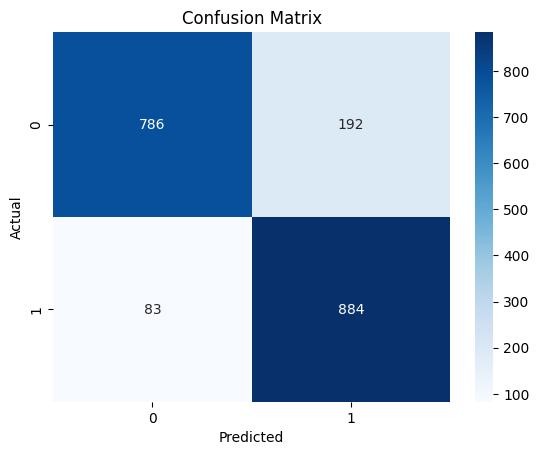

In [18]:
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85       978
           1       0.82      0.91      0.87       967

    accuracy                           0.86      1945
   macro avg       0.86      0.86      0.86      1945
weighted avg       0.86      0.86      0.86      1945

